<a href="https://colab.research.google.com/github/ava-ly/ds-projects/blob/main/Module_4_YouTube_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 4. Understanding Audience Sentiment

In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 6.8 MB/s eta 0:00:00


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the comments dataset and the older version of videos dataset
df_videos_v1 = pd.read_csv('https://media.githubusercontent.com/media/ava-ly/ds-projects/refs/heads/main/youtube/USvideos_v1.csv', engine='python', delimiter=',', on_bad_lines='skip')
df_comments = pd.read_csv('https://media.githubusercontent.com/media/ava-ly/ds-projects/refs/heads/main/youtube/UScomments_v1.csv', on_bad_lines='skip', low_memory=False)

In [ ]:
df_comments.shape

(691400, 4)

In [ ]:
df_comments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691400 entries, 0 to 691399
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   video_id      691400 non-null  object
 1   comment_text  691374 non-null  object
 2   likes         691400 non-null  object
 3   replies       691400 non-null  object
dtypes: object(4)
memory usage: 21.1+ MB


In [ ]:
df_comments.sample(5)

,video_id,comment_text,likes,replies
485303,H0bVlfJsR4Q,JUST A PRANK BRO,0,1
293753,vWmjyYh64vg,First found out about your channel from Doc Mo...,0,0
45635,Wb-6fhfAn2I,this does explain why when left to my own devi...,0,0
265231,OLTXWUWcwOo,This little boy is 23?!,0,0
684258,KQc7a_5G0pI,Habs is hockey thing,0,0


In [ ]:
# Instantiate the analyzer
analyzer = SentimentIntensityAnalyzer()

In [ ]:
df_comments['comment_text'].isnull().sum()

np.int64(26)

In [ ]:
# Handle missing comments
df_comments = df_comments.dropna(subset=['comment_text'])

print(f"New shape after dropping missing comments: {df_comments.shape}")

New shape after dropping missing comments: (691374, 4)


In [ ]:
# Define a function to get the sentiment score
def get_sentiment_score(text):
    return analyzer.polarity_scores(text)['compound']

In [ ]:
# Apply the function to the comment_text column
start_time = time.time()
df_comments['sentiment_score'] = df_comments['comment_text'].apply(get_sentiment_score)
end_time = time.time()
print(f"Time taken: {end_time - start_time:.2f} seconds")

Time taken: 102.55 seconds


In [ ]:
df_comments[['comment_text', 'sentiment_score']].sample(5)

,comment_text,sentiment_score
462216,no,-0.2960
569335,okay where is Pete? And .....And .... Just how...,0.7351
260518,Omg how long had it been since we've been to s...,0.0000
420058,Is she trying to fuck a puppet?,-0.5423
652992,Love you Beth 🍫🍫,0.6369


In [ ]:
# Aggregate Sentiment by Video
avg_sentiment_by_video = df_comments.groupby('video_id')['sentiment_score'].mean().reset_index()
avg_sentiment_by_video = avg_sentiment_by_video.rename(columns={'sentiment_score': 'avg_sentiment_score'})
avg_sentiment_by_video.sample(5)

,video_id,avg_sentiment_score
185,4NJYWgb6dQM,0.347439
251,658YZO_CmOk,0.080664
226,5Vd10gwNJRs,0.544511
396,AH0f3hesKjI,0.145700
255,6FgoZiTT52w,0.241801


In [ ]:
print(f"Number of unique videos with comment sentiment: {avg_sentiment_by_video.shape[0]}")

Number of unique videos with comment sentiment: 2266


In [ ]:
# Merge Sentiment Data into Main DataFrame
df_final = pd.merge(df_videos_v1, avg_sentiment_by_video, on='video_id', how='inner')

print(f"Final DataFrame shape: {df_final.shape}")

Final DataFrame shape: (7723, 12)


In [ ]:
print(f"Final missing values:\n {df_final[['title', 'likes', 'avg_sentiment_score']].isnull().sum()}")

title                  0
likes                  0
avg_sentiment_score    0
dtype: int64


In [ ]:
# Loading 'US_category_id.json' to map category_id numbers to category names
category_data = pd.read_json('https://raw.githubusercontent.com/ava-ly/ds-projects/refs/heads/main/youtube/US_category_id.json')

category_data['items'][0]
# Create a dictionary to map category IDs to category names
category_mapping = {int(item['id']): item['snippet']['title'] for item in category_data['items']}

df_final['category_name'] = df_final['category_id'].map(category_mapping)

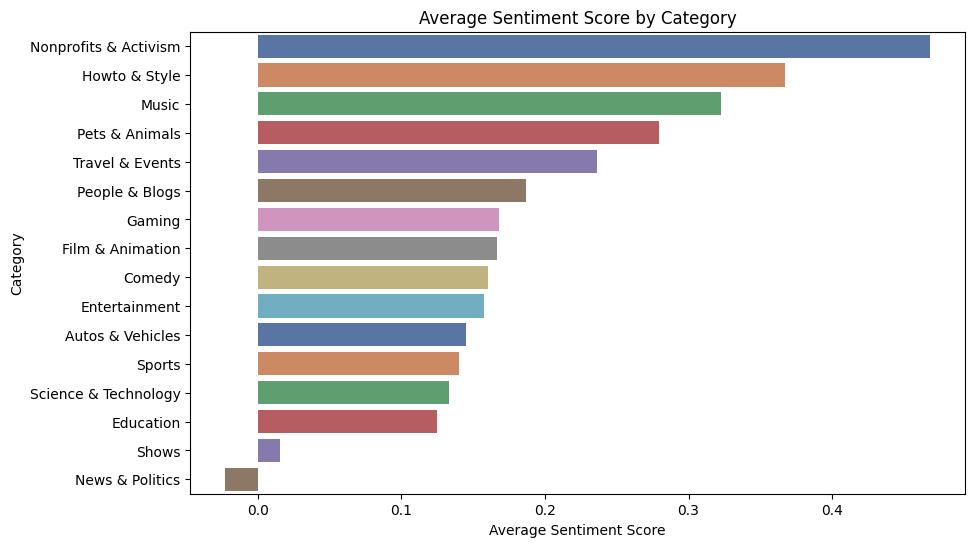

In [ ]:
# Analysis of Sentiment vs. Video Stats
# --- 1. What is the average sentiment per category? ---
avg_sentiment_by_category = df_final.groupby('category_name')['avg_sentiment_score'].mean().reset_index()
avg_sentiment_by_category = avg_sentiment_by_category.sort_values(by='avg_sentiment_score', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='avg_sentiment_score', y='category_name', data=avg_sentiment_by_category, orient='h', hue='category_name', palette='deep')
plt.title('Average Sentiment Score by Category')
plt.xlabel('Average Sentiment Score')
plt.ylabel('Category')
plt.show()

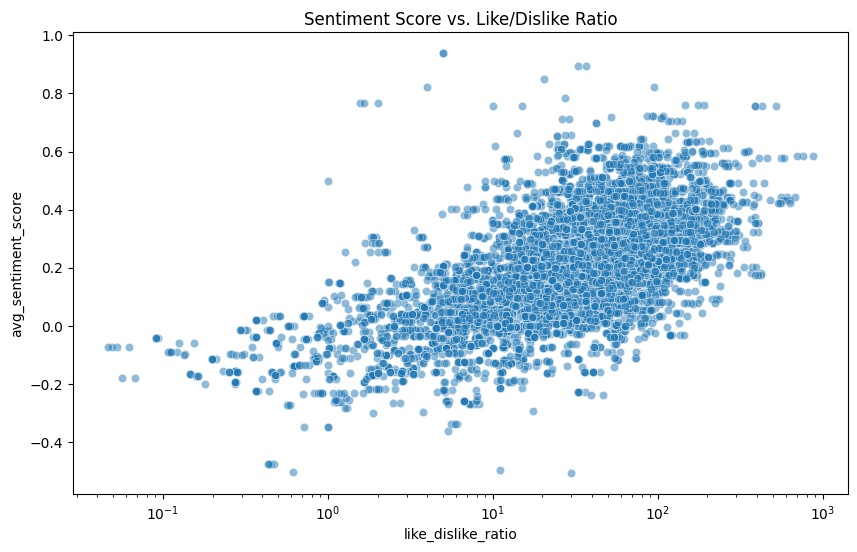

In [ ]:
# --- 2. Does sentiment correlate with the like/dislike ratio? ---
df_final['like_dislike_ratio'] = df_final['likes'] / (df_final['dislikes'] + 1)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x='like_dislike_ratio', y='avg_sentiment_score', alpha=0.5)
plt.xscale('log')
plt.title('Sentiment Score vs. Like/Dislike Ratio')
plt.show()

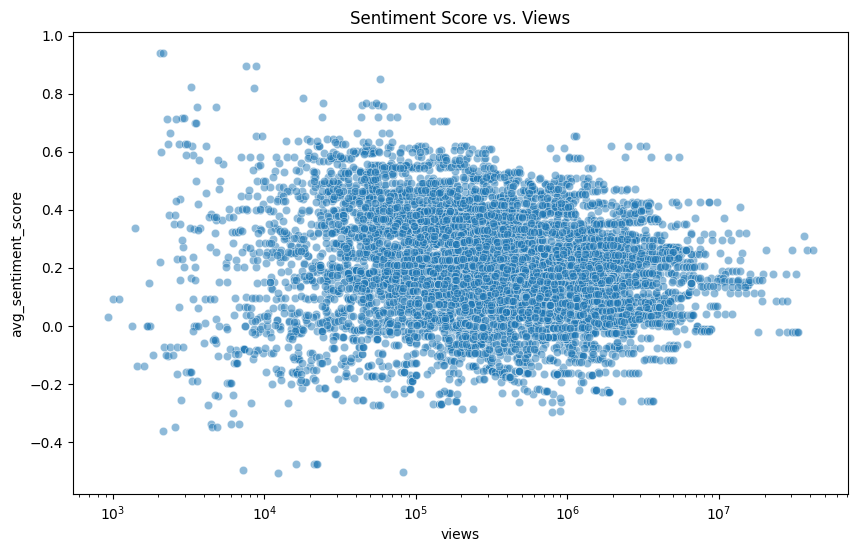

In [ ]:
# --- 3. Does sentiment correlate with view count? ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x='views', y='avg_sentiment_score', alpha=0.5)
plt.xscale('log')
plt.title('Sentiment Score vs. Views')
plt.show()

Observation:
- Nonprofits & Activism videos have the most positive sentiment while News & Politics have the negative sentiment which indicates the controvery of the topics/category.
- Obviously, the higher the like/dislike ratio, the more positive the sentiment.
- Sentiment score and views somehow cluster in the middle which doesn't mean the more views, the higher the sentiment score or vice versa.